In [ ]:
import pandas as pd
import re
import zipfile
import os
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/fake_news_dataset.csv')
zip_path = "/content/cyberbullying_tweets.csv.zip"
extract_path = "/content/datasets/"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extracted Successfully!")
print('fake news data',df)


Extracted Successfully!
fake news data                                            uuid  ord_in_thread  ... shares  type
0      6a175f46bcd24d39b3e962ad0f29936721db70db              0  ...      0  bias
1      2bdc29d12605ef9cf3f09f9875040a7113be5d5b              0  ...      0  bias
2      c70e149fdd53de5e61c29281100b9de0ed268bc3              0  ...      0  bias
3      7cf7c15731ac2a116dd7f629bd57ea468ed70284              0  ...      0  bias
4      0206b54719c7e241ffe0ad4315b808290dbe6c0f              0  ...      0  bias
...                                         ...            ...  ...    ...   ...
12994  f1b5d0e44803f48732bde854a9fdf95837219b12              2  ...      0    bs
12995  36011ceba3647e1bea78299b68b6fb705a1fc1ad              3  ...      0    bs
12996  6995d1aa9ac99926106489b14b5530e85358059a              4  ...      0    bs
12997  7de8ae90eee164eb756db6c8a3772288e11d7a94              5  ...      0    bs
12998  dabef7095b7d9dae6eb0d83c4cbb40b85efd7ae5              6  ...   

In [ ]:
cyber_df = pd.read_csv('/content/datasets/cyberbullying_tweets.csv')
print('Cyberbullying data:')
print(cyber_df.head())

Cyberbullying data:
                                          tweet_text cyberbullying_type
0  In other words #katandandre, your food was cra...  not_cyberbullying
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying


**Data** **Exploration**

In [ ]:
print(df.head())


Top 5 rows:
                                        uuid  ord_in_thread  ... shares  type
0  6a175f46bcd24d39b3e962ad0f29936721db70db              0  ...      0  bias
1  2bdc29d12605ef9cf3f09f9875040a7113be5d5b              0  ...      0  bias
2  c70e149fdd53de5e61c29281100b9de0ed268bc3              0  ...      0  bias
3  7cf7c15731ac2a116dd7f629bd57ea468ed70284              0  ...      0  bias
4  0206b54719c7e241ffe0ad4315b808290dbe6c0f              0  ...      0  bias

[5 rows x 20 columns]


In [ ]:
print(df.shape)

(12999, 20)


In [ ]:
print(df.columns)

Index(['uuid', 'ord_in_thread', 'author', 'published', 'title', 'text',
       'language', 'crawled', 'site_url', 'country', 'domain_rank',
       'thread_title', 'spam_score', 'main_img_url', 'replies_count',
       'participants_count', 'likes', 'comments', 'shares', 'type'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12999 entries, 0 to 12998
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   uuid                12999 non-null  object 
 1   ord_in_thread       12999 non-null  int64  
 2   author              10575 non-null  object 
 3   published           12999 non-null  object 
 4   title               12319 non-null  object 
 5   text                12953 non-null  object 
 6   language            12999 non-null  object 
 7   crawled             12999 non-null  object 
 8   site_url            12999 non-null  object 
 9   country             12823 non-null  object 
 10  domain_rank         8776 non-null   float64
 11  thread_title        12987 non-null  object 
 12  spam_score          12999 non-null  float64
 13  main_img_url        9356 non-null   object 
 14  replies_count       12999 non-null  int64  
 15  participants_count  12999 non-null  int64  
 16  like

In [ ]:
df.isnull().sum()

,0
uuid,0
ord_in_thread,0
author,2424
published,0
title,680
text,46
language,0
crawled,0
site_url,0
country,176


In [ ]:
df.drop_duplicates()

,uuid,ord_in_thread,author,published,title,text,language,crawled,site_url,country,domain_rank,thread_title,spam_score,main_img_url,replies_count,participants_count,likes,comments,shares,type
0,6a175f46bcd24d39b3e962ad0f29936721db70db,0,Barracuda Brigade,2016-10-26T21:41:00.000+03:00,Muslims BUSTED: They Stole Millions In Gov’t B...,Print They should pay all the back all the mon...,english,2016-10-27T01:49:27.168+03:00,100percentfedup.com,US,25689.0,Muslims BUSTED: They Stole Millions In Gov’t B...,0.000,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,0,1,0,0,0,bias
1,2bdc29d12605ef9cf3f09f9875040a7113be5d5b,0,reasoning with facts,2016-10-29T08:47:11.259+03:00,Re: Why Did Attorney General Loretta Lynch Ple...,Why Did Attorney General Loretta Lynch Plead T...,english,2016-10-29T08:47:11.259+03:00,100percentfedup.com,US,25689.0,Re: Why Did Attorney General Loretta Lynch Ple...,0.000,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,0,1,0,0,0,bias
2,c70e149fdd53de5e61c29281100b9de0ed268bc3,0,Barracuda Brigade,2016-10-31T01:41:49.479+02:00,BREAKING: Weiner Cooperating With FBI On Hilla...,Red State : \nFox News Sunday reported this mo...,english,2016-10-31T01:41:49.479+02:00,100percentfedup.com,US,25689.0,BREAKING: Weiner Cooperating With FBI On Hilla...,0.000,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,0,1,0,0,0,bias
3,7cf7c15731ac2a116dd7f629bd57ea468ed70284,0,Fed Up,2016-11-01T05:22:00.000+02:00,PIN DROP SPEECH BY FATHER OF DAUGHTER Kidnappe...,Email Kayla Mueller was a prisoner and torture...,english,2016-11-01T15:46:26.304+02:00,100percentfedup.com,US,25689.0,PIN DROP SPEECH BY FATHER OF DAUGHTER Kidnappe...,0.068,http://100percentfedup.com/wp-content/uploads/...,0,0,0,0,0,bias
4,0206b54719c7e241ffe0ad4315b808290dbe6c0f,0,Fed Up,2016-11-01T21:56:00.000+02:00,FANTASTIC! TRUMP'S 7 POINT PLAN To Reform Heal...,Email HEALTHCARE REFORM TO MAKE AMERICA GREAT ...,english,2016-11-01T23:59:42.266+02:00,100percentfedup.com,US,25689.0,FANTASTIC! TRUMP'S 7 POINT PLAN To Reform Heal...,0.865,http://100percentfedup.com/wp-content/uploads/...,0,0,0,0,0,bias
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12994,f1b5d0e44803f48732bde854a9fdf95837219b12,2,replaceme,2016-10-26T23:58:00.000+03:00,NaN,It DOES allow you to put a dog face on top of ...,english,2016-10-27T00:37:46.194+03:00,zerohedge.com,US,2435.0,"Snapchat To Raise Up To $4 Billion In IPO, Val...",0.000,NaN,40,32,0,0,0,bs
12995,36011ceba3647e1bea78299b68b6fb705a1fc1ad,3,Freedumb,2016-10-27T00:02:00.000+03:00,NaN,Wait till you see what happens to the valuatio...,english,2016-10-27T00:37:46.220+03:00,zerohedge.com,US,2435.0,"Snapchat To Raise Up To $4 Billion In IPO, Val...",0.000,NaN,40,32,0,0,0,bs
12996,6995d1aa9ac99926106489b14b5530e85358059a,4,major major maj...,2016-10-27T00:06:00.000+03:00,NaN,I'm waiting for the one that puts a pussy on m...,english,2016-10-27T00:37:46.244+03:00,zerohedge.com,US,2435.0,"Snapchat To Raise Up To $4 Billion In IPO, Val...",0.000,NaN,40,32,0,0,0,bs
12997,7de8ae90eee164eb756db6c8a3772288e11d7a94,5,beemasters,2016-10-27T00:09:00.000+03:00,NaN,$4 Billion even after they are known to be kee...,english,2016-10-27T00:37:46.247+03:00,zerohedge.com,US,2435.0,"Snapchat To Raise Up To $4 Billion In IPO, Val...",0.000,NaN,40,32,0,0,0,bs


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
le_fake = LabelEncoder()
df['label_encoded'] = le_fake.fit_transform(df['type'])
print("Original labels:", df['type'].unique())
print("Encoded labels:", df['label_encoded'].unique())

Original labels: ['bias' 'conspiracy' 'fake' 'bs' 'satire' 'hate' 'junksci' 'state']
Encoded labels: [0 2 3 1 6 4 5 7]


In [ ]:
le = LabelEncoder()
cyber_df['label_encoded'] = le.fit_transform(cyber_df['cyberbullying_type'])
print("Classes:", le.classes_)

Classes: ['age' 'ethnicity' 'gender' 'not_cyberbullying' 'other_cyberbullying'
 'religion']


In [ ]:
fake = pd.read_csv("/content/fake_news_dataset.csv")
fake['text'] = fake['text'].apply(clean_text)
fake['type'] = fake['type'].astype(str).str.lower().replace({'fake':1, 'real':0})
print("After cleaning:", fake.shape)

NameError: name 'pd' is not defined

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text


In [ ]:
cyber_df['clean_text'] = cyber_df['tweet_text'].apply(clean_text)
df['type'] = df['type'].apply(clean_text)

In [ ]:
X = cyber_df['clean_text']
y = cyber_df['label_encoded']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [ ]:

y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8097284830695042
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1598
           1       0.97      0.96      0.97      1592
           2       0.88      0.82      0.85      1595
           3       0.54      0.54      0.54      1589
           4       0.57      0.62      0.59      1565
           5       0.95      0.94      0.94      1600

    accuracy                           0.81      9539
   macro avg       0.81      0.81      0.81      9539
weighted avg       0.81      0.81      0.81      9539



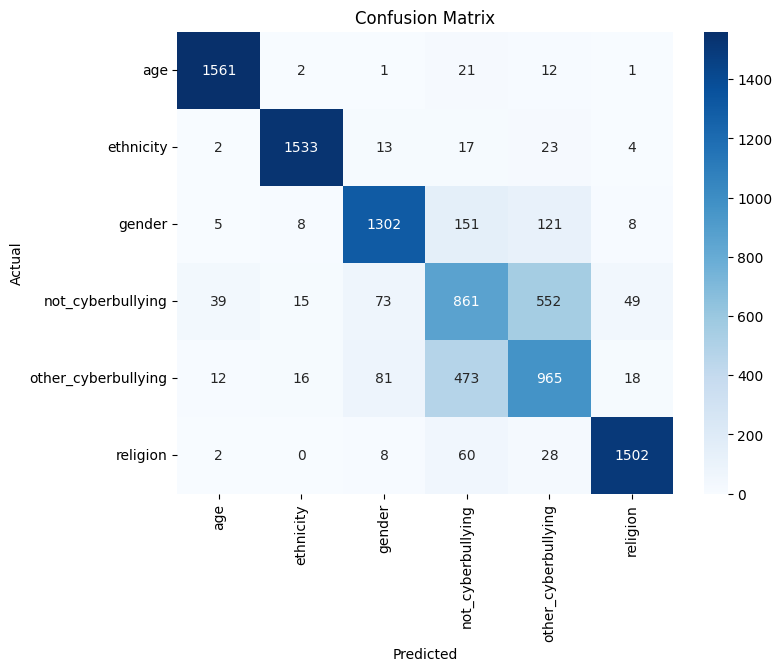

In [ ]:
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

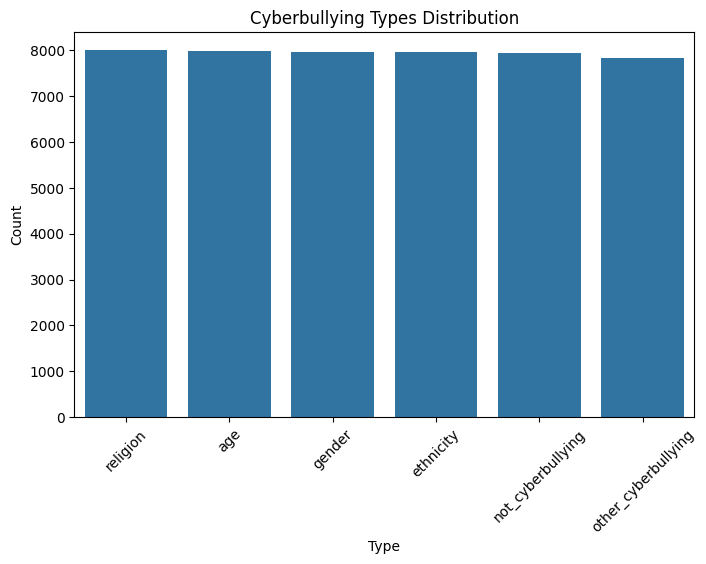

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.countplot(x='cyberbullying_type', data=cyber_df, order=cyber_df['cyberbullying_type'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Cyberbullying Types Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

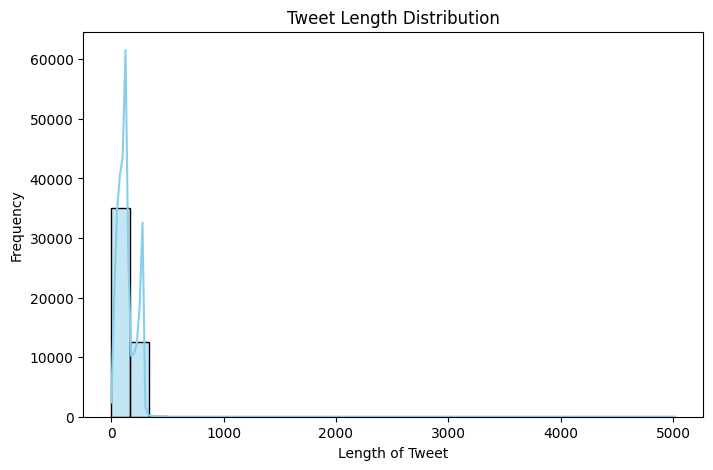

In [ ]:
cyber_df['text_length'] = cyber_df['tweet_text'].astype(str).apply(len)
plt.figure(figsize=(8,5))
sns.histplot(cyber_df['text_length'], bins=30, kde=True, color='skyblue')
plt.title("Tweet Length Distribution")
plt.xlabel("Length of Tweet")
plt.ylabel("Frequency")
plt.show()


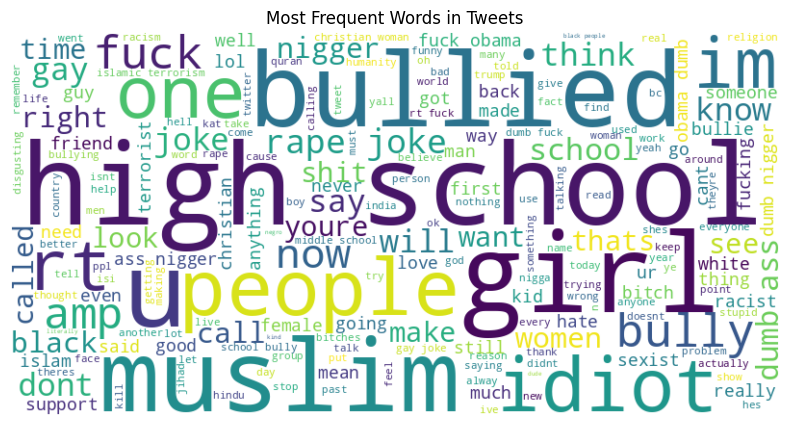

In [ ]:
from wordcloud import WordCloud
text = ' '.join(cyber_df['clean_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Tweets")
plt.show()